# AlphaForge — Exploratory Data Analysis

Phase-2 analytics for the AI-compute equity universe. The goal of this notebook is not just charts — it is to show the *reasoning* that the rest of AlphaForge is built on:

1. how the names co-move (and why that feeds the VaR engine),
2. their risk and quality/value factor structure, and
3. the **time-aware validation** discipline that keeps the ML model honest.

_Default data is synthetic and reproducible; run `python -m data_pipeline.ingest --live` first to analyse real market data instead._

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # project root
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4.5); plt.rcParams['axes.grid'] = True
from data_pipeline.db import init_db, connect
from data_pipeline.sample_data import generate
init_db()
with connect() as c:
    n = c.execute('SELECT COUNT(*) AS x FROM prices').fetchone()['x']
if not n:
    generate()
with connect() as c:
    px = c.read_df('SELECT ticker,date,close FROM prices')
    comp = c.read_df('SELECT ticker,sector FROM companies')
px['date'] = pd.to_datetime(px['date'])
wide = px.pivot(index='date', columns='ticker', values='close').sort_index()
rets = np.log(wide).diff().dropna()
print('universe:', list(wide.columns))
print('trading days:', len(wide), '| return obs:', len(rets))

Generated synthetic data for 10 tickers, 500 trading days each.
universe: ['AMD', 'ASML', 'AVGO', 'GOOGL', 'INTC', 'META', 'MSFT', 'MU', 'NVDA', 'TSM']
trading days: 500 | return obs: 499


## 1. How do the names co-move?

Correlation of daily log-returns. This is the matrix the risk engine decomposes (Cholesky) to draw correlated paths — co-movement is exactly what makes diversification *quantifiable*.

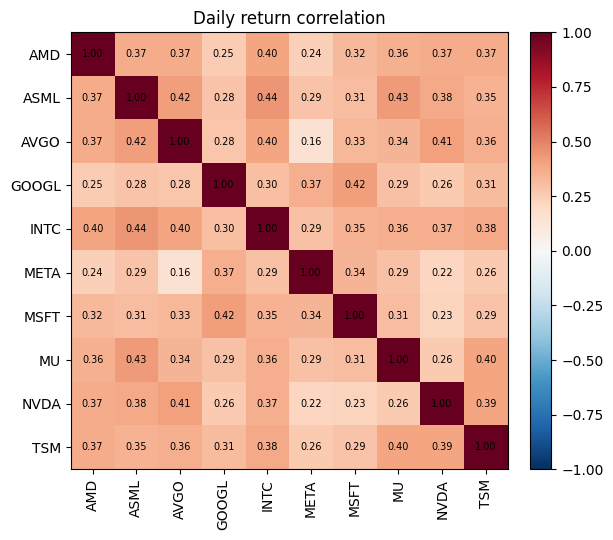

In [2]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Daily return correlation'); ax.grid(False); plt.tight_layout(); plt.show()

**Takeaway.** Names inside a sector co-move more than across sectors. That positive within-sector correlation is why an equal-weight semis basket's VaR is *higher* than diversifying across sectors would imply — and why the risk engine must model the full covariance, not just per-name volatility.

## 2. Risk: annualized volatility

Daily return std scaled by √252. The dispersion here is the raw material for position sizing and the VaR simulation.

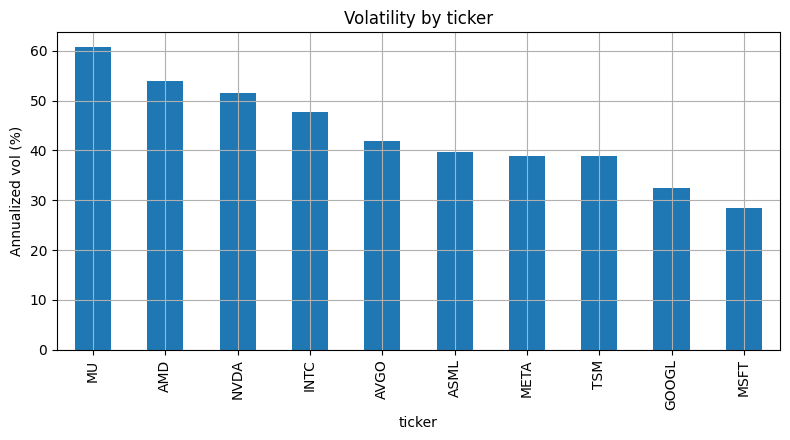

,ann_vol_%
ticker,
MU,60.6
AMD,53.8
NVDA,51.5
INTC,47.7
AVGO,41.8
ASML,39.7
META,38.9
TSM,38.8
GOOGL,32.4


In [3]:
vol = (rets.std() * np.sqrt(252) * 100).sort_values(ascending=False)
ax = vol.plot(kind='bar')
ax.set_ylabel('Annualized vol (%)'); ax.set_title('Volatility by ticker')
plt.tight_layout(); plt.show()
vol.round(1).to_frame('ann_vol_%')

**Takeaway.** The high-vol names dominate any equal-weight book's risk budget; this is the argument for risk-weighting rather than equal-weighting, and it is what the alert engine watches via the 95% VaR threshold.

## 3. Value vs quality (the screen the agent automates)

Each name plotted by valuation (EV/EBITDA, x) against quality (ROIC, y), sized by market cap and colored by DCF upside. The **top-left** quadrant — cheap *and* high-quality — is the classic value-quality screen.

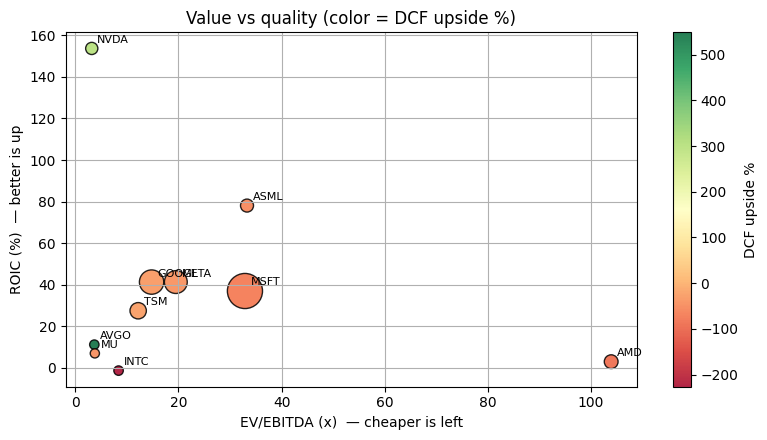

,ticker,sector,ev_ebitda,roic_pct,dcf_upside
0,NVDA,Semiconductors,3.2,153.7,298.1
1,AMD,Semiconductors,103.9,3.0,-86.9
2,AVGO,Semiconductors,3.7,11.2,548.6
3,TSM,Semiconductors,12.2,27.5,-24.1
4,ASML,Semiconductors,33.3,78.1,-51.8
5,MU,Semiconductors,3.8,7.0,-42.3
6,INTC,Semiconductors,8.4,-1.3,-226.3
7,MSFT,Software,32.9,37.0,-69.5
8,GOOGL,Software,14.8,41.3,-30.0
9,META,Software,19.5,41.3,-41.5


In [4]:
from finance.factors import factor_table
from finance.valuation import dcf
rows = factor_table()
df = pd.DataFrame(rows)
df['dcf_upside'] = [dcf(t).upside_pct for t in df['ticker']]
sub = df.dropna(subset=['ev_ebitda','roic_pct'])
fig, ax = plt.subplots()
sizes = (sub['market_cap'] / sub['market_cap'].max() * 600 + 40)
sc = ax.scatter(sub['ev_ebitda'], sub['roic_pct'], s=sizes,
                c=sub['dcf_upside'], cmap='RdYlGn', edgecolor='k', alpha=0.85)
for _, r in sub.iterrows():
    ax.annotate(r['ticker'], (r['ev_ebitda'], r['roic_pct']),
                fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel('EV/EBITDA (x)  — cheaper is left'); ax.set_ylabel('ROIC (%)  — better is up')
ax.set_title('Value vs quality (color = DCF upside %)')
fig.colorbar(sc, ax=ax, label='DCF upside %'); plt.tight_layout(); plt.show()
df[['ticker','sector','ev_ebitda','roic_pct','dcf_upside']].round(1)

**Takeaway.** This single view is what `screen` + `valuation` automate inside the agent: rank on cheapness and quality jointly, then let the DCF flag which of the high-quality names still offer upside.

## 4. The credibility check: time-aware validation

The most important chart in the project. We train the GBM classifier and compare AUC across a **time-ordered** train/validation/test split. If a model shows strong train AUC but its out-of-sample AUC collapses toward 0.5, that is the signal there is no real edge — and it is exactly what a leakage-free split is supposed to expose. (On synthetic data there is no alpha by construction, so this *should* happen.)

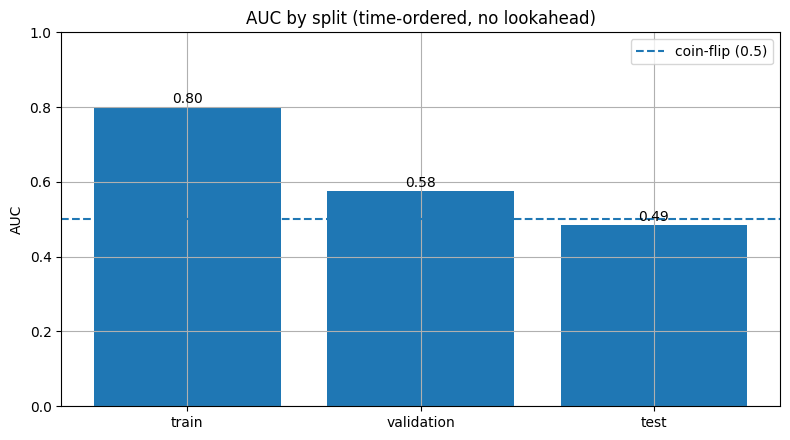

,n,base_rate,auc,accuracy
train,2490,0.5,0.801,0.712
validation,830,0.502,0.576,0.534
test,840,0.487,0.486,0.485


In [5]:
from models.train_classifier import train
m = train()
splits = ['train','validation','test']
aucs = [m[s].get('auc', float('nan')) for s in splits]
ax = plt.subplot()
bars = ax.bar(splits, aucs)
ax.axhline(0.5, linestyle='--', label='coin-flip (0.5)')
for b, a in zip(bars, aucs):
    ax.text(b.get_x()+b.get_width()/2, a+0.01, f'{a:.2f}', ha='center')
ax.set_ylim(0, 1); ax.set_ylabel('AUC'); ax.legend()
ax.set_title('AUC by split (time-ordered, no lookahead)')
plt.tight_layout(); plt.show()
pd.DataFrame({s: m[s] for s in splits}).T[['n','base_rate','auc','accuracy']]

**Takeaway.** Train AUC ≫ test AUC here is the validation harness *working*. A naive random split would have leaked overlapping-window information across the boundary and reported a flatteringly high test score — the classic finance-ML trap. Swap in real data (`--live`) to test for genuine signal; the honest expectation is that it is small and hard-won.

## Conclusions

- The universe co-moves within sectors → diversification is real and the VaR engine models it via the return covariance.
- Volatility dispersion argues for risk-weighting, which the alert engine monitors.
- A joint value–quality screen, confirmed by a DCF, is the core idea the agent automates.
- A time-aware split keeps the ML claims honest — the single most important discipline in finance ML, and the thing a reviewer should check first.